In [25]:
import time
import numpy as np
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup

from utils.colors import CMAP
from utils.plotting import save_plot
import matplotlib.patches as patches

from algorithms.cg_solvers import DynamicalLowRankPCG
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SETUP = TestProblemsSetup(n=64)
PROBLEM_PARAMS = SETUP.problem_params
PROBLEMS = SETUP.get_test_problems()
SEED = 15

In [19]:
def as_func(x, V_h):
    f = Function(V_h)
    f.vector()[:] = x
    return f


def plot_multiple_f(solutions, pid, labels=None, fig_name=None, shrink=0.3, outline_truth=True, colorbar=False):
    pb = PROBLEMS[pid]
    PARAMS = PROBLEM_PARAMS[pid]
    f_list = [as_func(x, pb['V_h']) for x in solutions]

    width, height = PARAMS['width'], PARAMS['height']
    x0s, y0s = PARAMS['x0'], PARAMS['y0']

    fig, axes = plt.subplots(1, len(f_list), figsize=(9, 6.06), constrained_layout=True)

    if labels is None: labels = ['' for _ in axes.flat]

    for ax, func, label in zip(axes.flat, f_list, labels):
        plt.sca(ax)
        #vmin = np.min(func.vector().get_local())

        p = plot(func, cmap=CMAP)
        if colorbar: fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(label, labelpad=10)

        if outline_truth:
            for x0, y0 in zip(x0s, y0s):
                square = patches.Rectangle(
                    (x0, y0), width, height,
                    edgecolor="white",
                    facecolor="none"
                )
                ax.add_patch(square)

    save_plot(fig_name=fig_name)
    plt.show()


---
**Trying different preconditioners**


In [20]:

def experiment(param_grid, default_args, pid, k=50):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=k, seed=SEED)
    w = rsvd.weights()

    errors, solutions, residuals = [], [], []
    
    for params in param_grid:
        solver = DynamicalLowRankPCG(rsvd, pb['x'])
        x = solver.solve(pb['y'], w, **default_args, **params, seed=SEED)
        
        errors.append(solver.error.copy())
        residuals.append(solver.residual.copy())
        solutions.append(x)

    return {'solutions': solutions, 'errors': errors, 'residuals': residuals}

In [21]:
# DLRA-PCG without restarting
param_grid = [
    {'preconditioner': 'none',        'max_iter': 500},
    {'preconditioner': 'jacobi',      'max_iter': 500},
    {'preconditioner': 'ic',          'max_iter': 500},
    {'preconditioner': 'ic-woodbury', 'max_iter': 3},
    {'preconditioner': 'perfect',     'max_iter': 2},
]
default_args = {'lambda_': 1e-4, 'max_rank': 1, 'rtol': 0, 'etol': 0}
resultsI = experiment(param_grid, default_args, pid='I')

# DLRA-PCG with restarting
param_grid = [
    {'preconditioner': 'none',        'max_iter': 25000, 'restart_every': 10},
    {'preconditioner': 'jacobi',      'max_iter': 25000, 'restart_every': 10},
    {'preconditioner': 'ic',          'max_iter': 5000,  'restart_every': 10},
    {'preconditioner': 'ic-woodbury', 'max_iter': 1000,  'restart_every': 10},
    {'preconditioner': 'perfect',     'max_iter': 4,     'restart_every': 10}
]
default_args = {'lambda_': 1e-4, 'max_rank': 1, 'rtol': 0, 'etol': 0}
results_diverge = experiment(param_grid, default_args, pid='I')

[##############################] 500/500
[##############################] 500/500
[##############################] 500/500
[##############################] 3/3
[##############################] 2/2
[##############################] 25000/25000
[##############################] 25000/25000
[##############################] 5000/5000
[##############################] 1000/1000
[##############################] 4/4


In [22]:
for e, p in zip(resultsI['errors'], param_grid):
    print(p['preconditioner'], e[-1])

none 0.8112147446759227
jacobi 0.8063830191941037
ic 0.857058962293711
ic-woodbury 0.8366549648092572
perfect 0.8364926817920921


../../figures/number_of_iterations_preconditioners.png already exists


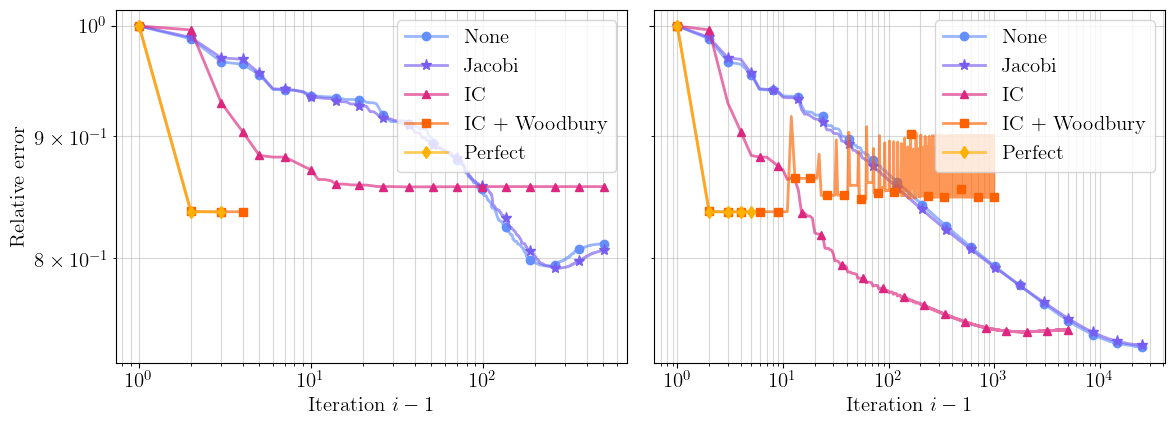

In [ ]:
def plot_errors(e_list, names=None, fig_name=None, n_marks=20, ax=None, ylim=None, ylabel=True):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    if ax is None: fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    else: fig = ax.figure
    if names is None: names = ['' for _ in e_list]

    for i, e in enumerate(e_list):
        x = np.arange(1, len(e) + 1)

        x_marks = np.logspace(np.log10(x[0]), np.log10(x[-1]), n_marks)
        mark_idx = np.unique([np.abs(x - xm).argmin() for xm in x_marks])

        ax.loglog(x, e, lw=2.0, label=names[i], markevery=mark_idx, c=C5[i], alpha=.65)
        ax.loglog(x, e, M[i], lw=2.0, markevery=mark_idx, ms=MS[i], c=C5[i])

    if ylim is not None: ax.set_ylim(ylim)

    handles, labels = [], names
    for i in range(len(e_list)):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=2.0, alpha=.65)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    if ylabel: ax.set_ylabel('Relative error')
    ax.set_xlabel('Iteration $i - 1$')
    ax.grid(True, which='both', alpha=.5)
    ax.legend(handles=handles, labels=labels, loc='upper right')

    if fig_name is not None:
        save_plot(fig_name)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

names = ['None', 'Jacobi', 'IC', 'IC + Woodbury', 'Perfect']
plot_errors(resultsI['errors'],  names=names, ax=axes[0])
plot_errors(results_diverge['errors'], names=names, ax=axes[1], ylabel=False)

plt.tight_layout()
save_plot('number_of_iterations_preconditioners')
plt.show()

In [26]:
pb   = PROBLEMS['I']
rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=50, seed=SEED)
w    = rsvd.weights()
lam  = 1e-4

configs = [
    ('None',       'none',       None),
    ('Jacobi',     'jacobi',     None),
    ('IC',         'ic',         None),
    ('IC+Woodbury','ic-woodbury', None),
]

N_ITER = 300
N_RUNS = 51

for name, precond in [('None','none'), ('Jacobi','jacobi'),
                       ('IC','ic'), ('IC+Woodbury','ic-woodbury')]:
    setup_times, total_times = [], []

    for _ in range(N_RUNS):
        solver = DynamicalLowRankPCG(rsvd, pb['x'])

        t0 = time.perf_counter()
        solver.get_preconditioner(w, lam, precond)
        setup_times.append((time.perf_counter() - t0) * 1e3)

        t0 = time.perf_counter()
        solver.solve(pb['y'], w, lam, preconditioner=precond,
                     max_iter=N_ITER, max_rank=1, rtol=0, seed=SEED, verbose=False)
        total_times.append((time.perf_counter() - t0) * 1e3)

    setup   = np.median(setup_times)
    per_iter = (np.median(total_times) - setup) / N_ITER  # subtract setup built inside solve
    print(f"{name:<12}  setup: {setup:6.1f} ms   per-iter: {per_iter:.2f} ms")



None          setup:    0.0 ms   per-iter: 0.74 ms
Jacobi        setup:    1.7 ms   per-iter: 0.75 ms
IC            setup:    4.4 ms   per-iter: 0.80 ms
IC+Woodbury   setup:   10.9 ms   per-iter: 1.17 ms


---
**Iteration count table**

In [9]:
param_grid = [
    {'preconditioner': 'none',        'max_iter': 25000},
    {'preconditioner': 'none',        'max_iter': 25000, 'restart_every': 10},
    {'preconditioner': 'none',        'max_iter': 25000, 'restart_every': 25},

    {'preconditioner': 'jacobi',      'max_iter': 25000},
    {'preconditioner': 'jacobi',      'max_iter': 25000, 'restart_every': 10},
    {'preconditioner': 'jacobi',      'max_iter': 25000, 'restart_every': 25},

    {'preconditioner': 'ic',          'max_iter': 3000},
    {'preconditioner': 'ic',          'max_iter': 3000, 'restart_every': 10},
    {'preconditioner': 'ic',          'max_iter': 3000, 'restart_every': 25},

    {'preconditioner': 'ic-woodbury', 'max_iter': 2},
    {'preconditioner': 'perfect',     'max_iter': 2},
]
default_args = {'lambda_': 1e-4, 'max_rank': 1, 'rtol': 0, 'etol': 0}
results_table = experiment(param_grid, default_args, pid='I')

[##############################] 25000/25000
[##############################] 25000/25000
[##############################] 25000/25000
[##############################] 25000/25000
[##############################] 25000/25000
[##############################] 25000/25000
[##############################] 3000/3000
[##############################] 3000/3000
[##############################] 3000/3000
[##############################] 2/2
[##############################] 2/2


In [10]:
#results_table['errors']
etols = [0.90, 0.85, 0.80, 0.75]
names = [p['preconditioner'].capitalize() for p in param_grid]

N_r_list = [str(p.get('restart_every', '$\infty$'))for p in param_grid]

for name, N_r, e in zip(names, N_r_list, results_table['errors']):
    e_arr = np.array(e)
    vals = []
    for tol in etols:
        hits = np.where(e_arr < tol)[0] 
        vals.append(str(int(hits[0])) if len(hits) > 0 else r'\texttt{-}')
    print(f"& {N_r} & {' & '.join(vals)} \\\\")

& $\infty$ & 48 & 100 & 184 & \texttt{-} \\
& 10 & 35 & 165 & 816 & 5941 \\
& 25 & 54 & 249 & 958 & \texttt{-} \\
& $\infty$ & 43 & 112 & 204 & \texttt{-} \\
& 10 & 34 & 145 & 776 & 6518 \\
& 25 & 50 & 250 & 1042 & \texttt{-} \\
& $\infty$ & 4 & \texttt{-} & \texttt{-} & \texttt{-} \\
& 10 & 4 & 14 & 30 & 680 \\
& 25 & 4 & 28 & 57 & \texttt{-} \\
& $\infty$ & 1 & 1 & \texttt{-} & \texttt{-} \\
& $\infty$ & 1 & 1 & \texttt{-} & \texttt{-} \\


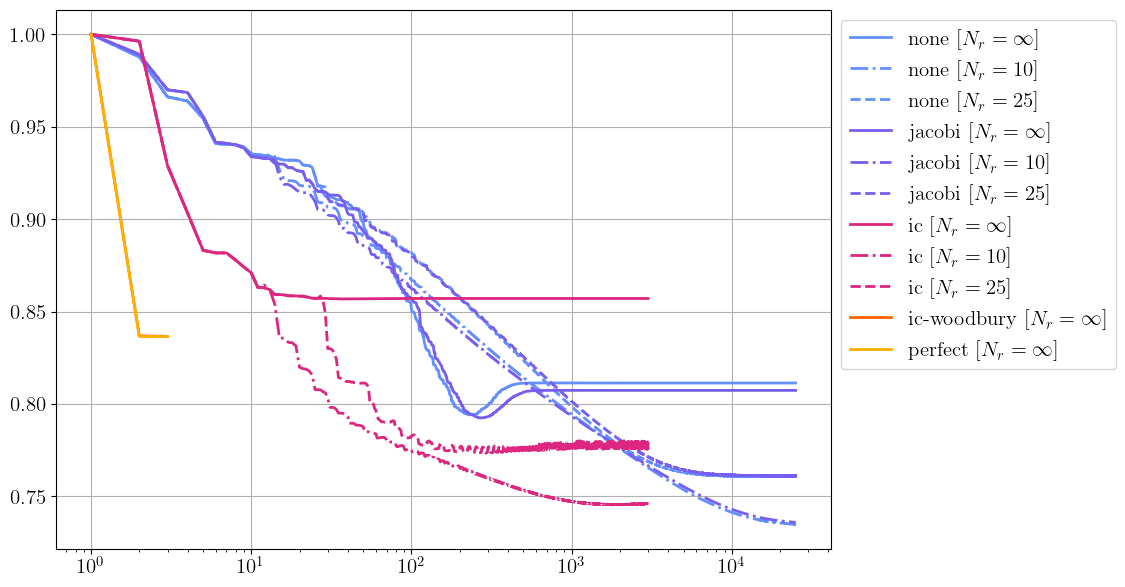

In [22]:
names = [
    p['preconditioner'] + " [$N_r = " + str(p.get('restart_every', '\infty')) + "$]"
    for p in param_grid
]

def name_to_c(name):
    from utils.colors import C5
    if 'none' in name: return C5[0]
    if 'jacobi' in name: return C5[1]
    if 'ic-woodbury' in name: return C5[3]
    if 'ic' in name: return C5[2]
    return C5[4]

def Nr_to_ls(name):
    if 'infty' in name: return '-'
    if '25' in name: return '--'
    if '10' in name: return '-.'

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
for e, name in zip(results_table['errors'], names):
    ax.semilogx(
        np.arange(1, len(e)+1), e,
        label=name, c=name_to_c(name), ls=Nr_to_ls(name),
        lw=2
    )

ax.legend(bbox_to_anchor=(1, 1))
ax.grid()
plt.show()